In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
df.shape

(303, 14)

## Observation

- The dataset contains **303 patient records**.
- There are **14 columns**, including the target variable.
- This is a relatively small structured dataset, making it suitable for classical machine learning algorithms such as Logistic Regression, Random Forest, Decision Trees, and XGBoost.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


## Observation

- The statistical summary provides an overview of each numerical feature.
- Most patient ages fall between 29 and 77 years.
- Cholesterol and resting blood pressure show a wide range of values.
- These statistics help identify potential outliers and understand the overall data distribution before preprocessing.

In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

## Observation

- The `ca` column contains 4 missing values.
- The `thal` column contains 2 missing values.
- All other features are complete.
- These missing values will be handled during the data preprocessing stage.

In [11]:
df.duplicated().sum()

0

In [12]:
df["target"] = (df["target"] > 0).astype(int)

df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

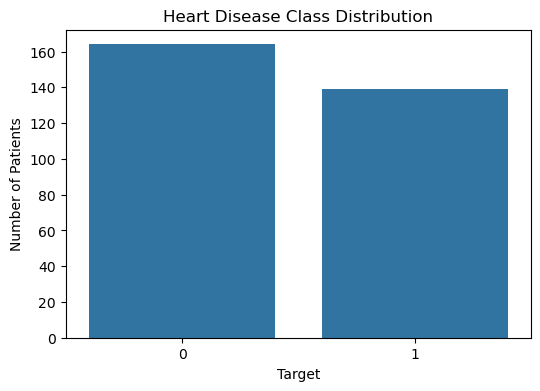

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x="target", data=df)

plt.title("Heart Disease Class Distribution")

plt.xlabel("Target")

plt.ylabel("Number of Patients")

plt.show()

## Observation

- The dataset contains approximately **164 patients without heart disease** and **139 patients with heart disease**.
- The class distribution is reasonably balanced.
- Since there is no severe class imbalance, standard evaluation metrics such as Accuracy, Precision, Recall, and F1-score can be used for model evaluation.

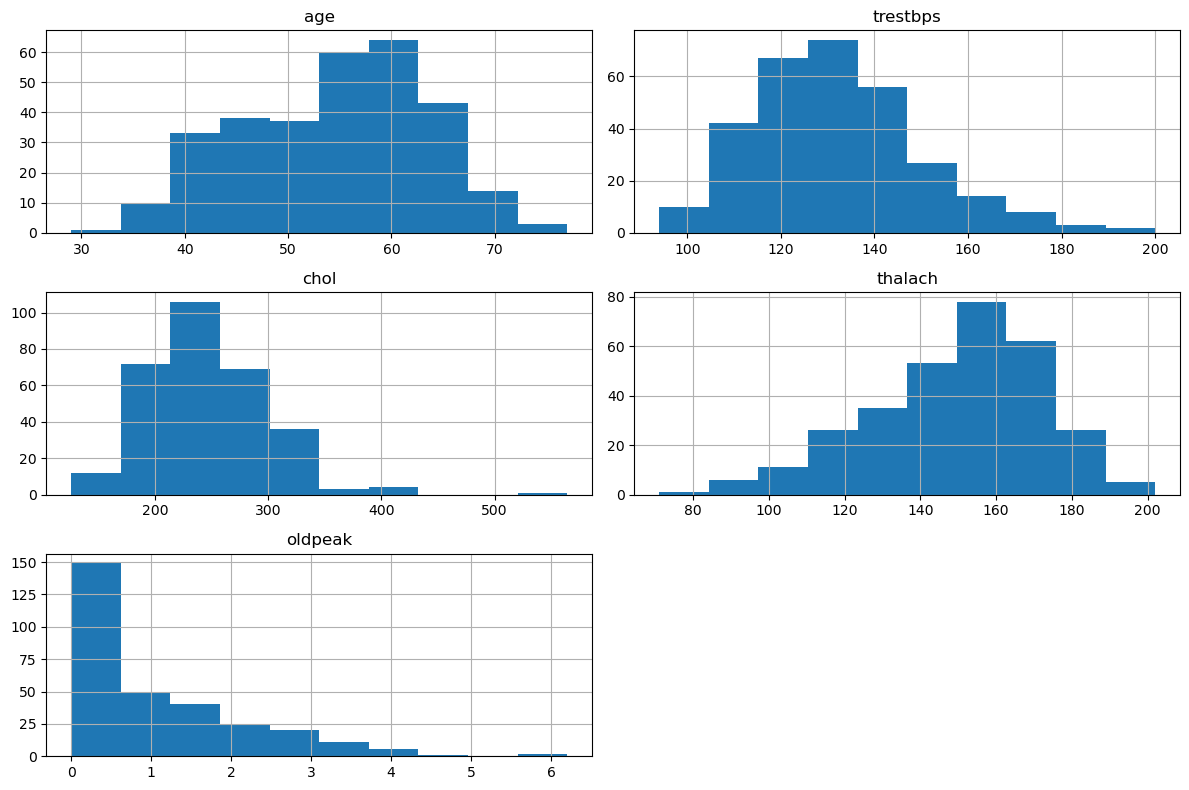

In [16]:
df[["age", "trestbps", "chol", "thalach", "oldpeak"]].hist(figsize=(12,8))

plt.tight_layout()

plt.show()

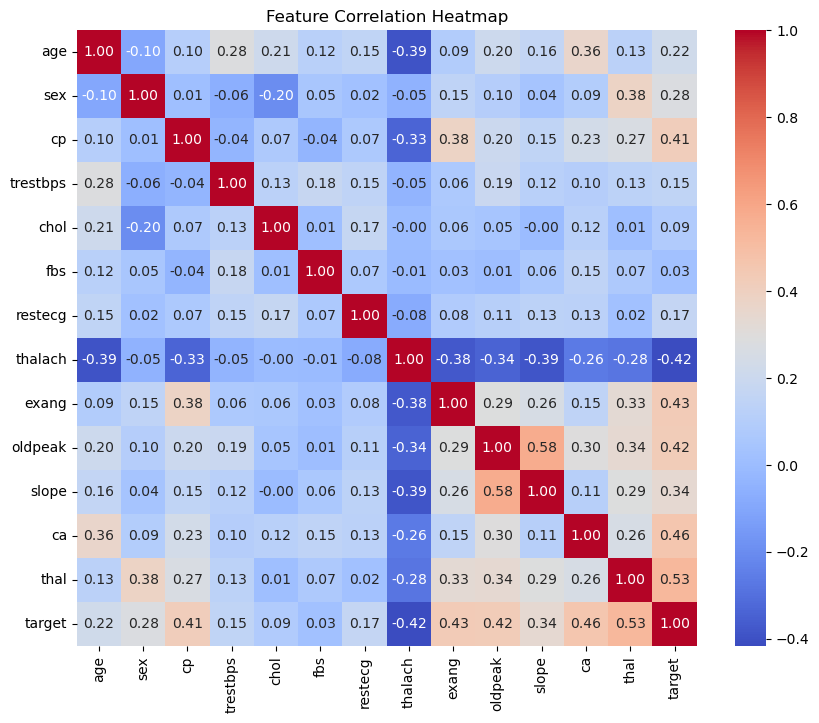

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

## Observation

- The heatmap shows relationships between all numerical features.
- Some features such as chest pain type (cp) and maximum heart rate (thalach) show stronger correlation with the target variable.
- Features like cholesterol may have weaker correlation.
- This helps in feature selection during model building.

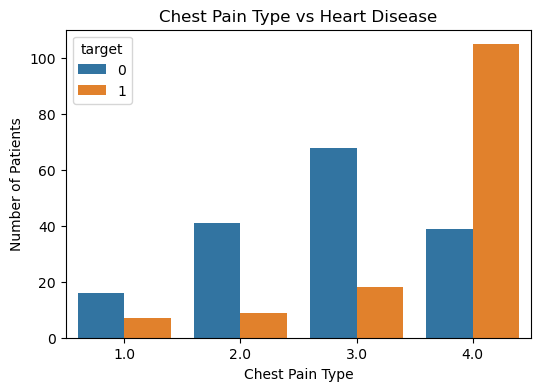

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x="cp", hue="target", data=df)

plt.title("Chest Pain Type vs Heart Disease")

plt.xlabel("Chest Pain Type")

plt.ylabel("Number of Patients")

plt.show()

In [33]:
df["ca"] = df["ca"].fillna(df["ca"].mode()[0])

df["thal"] = df["thal"].fillna(df["thal"].mode()[0])

In [35]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [37]:
df.to_csv("../data/processed/heart_processed.csv", index=False)

In [39]:
git add .
git commit -m "Completed EDA and data preprocessing"
git push

SyntaxError: invalid syntax (3072159414.py, line 1)